# Poverty and Race in the MORPC 15-County Region

This notebook walks through a realistic analysis scenario using `morpc-census`:

1. **Variable discovery** — find the Census tables for poverty status by race
2. **Fetch** — retrieve data for all 15 MORPC counties
3. **Snapshot** — compare poverty rates by race/ethnicity group, 2024, with reliability filtering
4. **Time series** — track changes in non-white poverty rates, 2019–2024
5. **Map** — choropleth of non-white poverty change by county

> **ACS 5-year note:** Each vintage year covers a 5-year period (e.g., 2024 covers 2020–2024). Consecutive years overlap by four years and are not statistically independent measurements.

In [22]:
from morpc_census import (
    Endpoint, Group, CensusAPI, DimensionTable, RaceDimensionTable,
    RACE_TABLE_MAP, HIGHLEVEL_DESC_TO_ID,
    fetch_geos_from_scope_sumlevel,
)
import pandas as pd
import numpy as np

## 1. Variable discovery


> ***Network required** — the cells below make live calls to the Census API.*

Start with an `Endpoint` and search `endpoint.groups` for tables related to the topic. We can think of an endpoint as specific survey and year/vintage.

> The ACS 5-year survey has hundreds of groups; filtering by keyword narrows the field quickly.

In [125]:
ep = Endpoint('acs/acs5', 2024)

ep.search_groups('poverty')

{'B05010': 'Ratio of Income to Poverty Level in the Past 12 Months by Nativity of Children Under 18 Years in Families and Subfamilies by Living Arrangements and Nativity of Parents',
 'B06012': 'Place of Birth by Poverty Status in the Past 12 Months in the United States',
 'B06012PR': 'Place of Birth by Poverty Status in the Past 12 Months in Puerto Rico',
 'B07012': 'Geographical Mobility in the Past Year by Poverty Status in the Past 12 Months for Current Residence in the United States',
 'B07012PR': 'Geographical Mobility in the Past Year by Poverty Status in the Past 12 Months for Current Residence in Puerto Rico',
 'B07412': 'Geographical Mobility in the Past Year by Poverty Status in the Past 12 Months for Residence 1 Year Ago in the United States',
 'B07412PR': 'Geographical Mobility in the Past Year by Poverty Status in the Past 12 Months for Residence 1 Year Ago in Puerto Rico',
 'B08122': 'Means of Transportation to Work by Poverty Status in the Past 12 Months',
 'B08522': 'M

**B17001** - *Poverty Status by Sex by Age* is the standard person-level poverty table.

We can look at the groups description and universe by creating a Group object.

In [28]:
g = Group(ep, 'B17001')
print(f"Description : {g.description}")
print(f"Universe    : {g.universe}")

Description : Poverty Status in the Past 12 Months by Sex by Age
Universe    : Population for whom poverty status is determined


To look at the rate of poverty we can call DimensionTable.percent() which will calculate the percent of each row based on the total.

The .drop() method allows us to drop unwanted dimension in the data, in this case sex and age. 

In [76]:
dim = DimensionTable(CensusAPI(ep, group=g, scope='region15').long).drop(['dim_2', 'dim_3']).percent()
dim

concept                                                  Poverty status in the past 12 months by sex by age  \
universe                                                   Population for whom poverty status is determined   
survey                                                                                             acs/acs5   
geoidfq                                                                                      0500000US39041   
name                                                                                  Delaware County, Ohio   
reference_period                                                                                       2024   
                                                                                                   estimate   
dim_0 dim_1                                                                                                   
Total Income in the past 12 months below poverty level                                                 4.67   
      Income in the past 12 months at or above povert...                                              95.33   

concept                                                         \
universe                                                         
survey                                                           
geoidfq                                                          
name                                                             
reference_period                                                 
                                                           moe   
dim_0 dim_1                                                      
Total Income in the past 12 months below poverty level    0.60   
      Income in the past 12 months at or above povert...  0.59   

concept                                                                          \
universe                                                                          
survey                                                                            
geoidfq                                                          0500000US39045   
name                                                     Fairfield County, Ohio   
reference_period                                                           2024   
                                                                       estimate   
dim_0 dim_1                                                                       
Total Income in the past 12 months below poverty level                     8.01   
      Income in the past 12 months at or above povert...                  91.99   

concept                                                         \
universe                                                         
survey                                                           
geoidfq                                                          
name                                                             
reference_period                                                 
                                                           moe   
dim_0 dim_1                                                      
Total Income in the past 12 months below poverty level    0.78   
      Income in the past 12 months at or above povert...  0.71   

concept                                                                        \
universe                                                                        
survey                                                                          
geoidfq                                                        0500000US39047   
name                                                     Fayette County, Ohio   
reference_period                                                         2024   
                                                                     estimate   
dim_0 dim_1                                                                     
Total Income in the past 12 months below poverty level                  15.53   
      I

**B17001A-I** - *Poverty Status in the Past 12 Months by Sex by Age (by Race)* are race tables which separate poverty status by race. 

morpc-census allows us to call all of these table in the same format and concatenating them to compare across race.

In [77]:
race_groups = {value: Group(ep, f"B17001{key}") for key, value in RACE_TABLE_MAP.items()}

In [78]:
[v.description for k, v in race_groups.items()]

['Poverty Status in the Past 12 Months by Sex by Age (White Alone)',
 'Poverty Status in the Past 12 Months by Sex by Age (Black or African American Alone)',
 'Poverty Status in the Past 12 Months by Sex by Age (American Indian and Alaska Native Alone)',
 'Poverty Status in the Past 12 Months by Sex by Age (Asian Alone)',
 'Poverty Status in the Past 12 Months by Sex by Age (Native Hawaiian and Other Pacific Islander Alone)',
 'Poverty Status in the Past 12 Months by Sex by Age (Some Other Race Alone)',
 'Poverty Status in the Past 12 Months by Sex by Age (Two or More Races)',
 'Poverty Status in the Past 12 Months by Sex by Age (White Alone, Not Hispanic or Latino)',
 'Poverty Status in the Past 12 Months by Sex by Age (Hispanic or Latino)']

## 2. Fetching data

For the poverty-by-race snapshot we need two variables from each racial iteration table:

CensusAPI allows us to call a list of variables across groups. We can use this to call the variables needed from each race table.

| Variable | Meaning |
|---|---|
| `B17001X_001E` | Total population for whom poverty status is determined |
| `B17001X_002E` | Population with income below the poverty level |

The Census API returns a **margin of error** (MOE) alongside every estimate.
MOEs are reported at the 90% confidence level and appear in the `moe` column of `.long`.

In [79]:
race_vars = []
for code in RACE_TABLE_MAP:
    race_vars += [f'B17001{code}_001E', f'B17001{code}_001M', f'B17001{code}_002E', f'B17001{code}_002M']

race_api = CensusAPI(ep, 'region15', variables=race_vars)
race_api.long

,geoidfq,name,reference_period,survey,concept,universe,variable_label,variable,estimate,moe
14,0500000US39041,"Delaware County, Ohio",2024,acs/acs5,Poverty status in the past 12 months by sex by...,White alone population for whom poverty status...,Total:,B17001A_001,179355,999
15,0500000US39041,"Delaware County, Ohio",2024,acs/acs5,Poverty status in the past 12 months by sex by...,White alone population for whom poverty status...,Total:!!Income in the past 12 months below pov...,B17001A_002,7818,1035
4,0500000US39041,"Delaware County, Ohio",2024,acs/acs5,Poverty status in the past 12 months by sex by...,Black or African American alone population for...,Total:,B17001B_001,9616,568
5,0500000US39041,"Delaware County, Ohio",2024,acs/acs5,Poverty status in the past 12 months by sex by...,Black or African American alone population for...,Total:!!Income in the past 12 months below pov...,B17001B_002,1026,592
0,0500000US39041,"Delaware County, Ohio",2024,acs/acs5,Poverty status in the past 12 months by sex by...,American Indian and Alaska Native alone popula...,Total:,B17001C_001,104,53
...,...,...,...,...,...,...,...,...,...,...
265,0500000US39159,"Union County, Ohio",2024,acs/acs5,Poverty status in the past 12 months by sex by...,Two or more races population for whom poverty ...,Total:!!Income in the past 12 months below pov...,B17001G_002,233,155
268,0500000US39159,"Union County, Ohio",2024,acs/acs5,Poverty status in the past 12 months by sex by...,"White alone, not Hispanic or Latino population...",Total:,B17001H_001,54950,355
269,0500000US39159,"Union County, Ohio",2024,acs/acs5,Poverty status in the past 12 months by sex by...,"White alone, not Hispanic or Latino population...",Total:!!Income in the past 12 months below pov...,B17001H_002,2946,615
258,0500000US39159,"Union County, Ohio",2024,acs/acs5,Poverty status in the past 12 months by sex by...,Hispanic or Latino population for whom poverty...,Total:,B17001I_001,2173,63


## 3. Poverty by race — 2024 snapshot

For each racial group, the poverty rate is the share of people in that group whose income
falls below the federal poverty level:

morpc-census provides a DimensionTable and RaceDimensionTable to look at human-readable, wide format tables



In [118]:
wide = RaceDimensionTable(race_api.long).percent()
wide

concept                                                      Poverty status in the past 12 months by sex by age  \
universe                                               Population of race for whom poverty status is determined   
survey                                                                                                 acs/acs5   
geoidfq                                                                                          0500000US39041   
name                                                                                      Delaware County, Ohio   
race                                                                                                White Alone   
reference_period                                                                                           2024   
value_type                                                                                             estimate   
dim_0 dim_1                                                                                                       
Total Income in the past 12 months below poverty level                                               4.36         

concept                                                       \
universe                                                       
survey                                                         
geoidfq                                                        
name                                                           
race                                                           
reference_period                                               
value_type                                               moe   
dim_0 dim_1                                                    
Total Income in the past 12 months below poverty level  0.58   

concept                                                                                 \
universe                                                                                 
survey                                                                                   
geoidfq                                                                                  
name                                                                                     
race                                                   Black or African American Alone   
reference_period                                                                  2024   
value_type                                                                    estimate   
dim_0 dim_1                                                                              
Total Income in the past 12 months below poverty level                           10.67   

concept                                                       \
universe                                                       
survey                                                         
geoidfq                                                        
name                                                           
race                                                           
reference_period                                               
value_type                                               moe   
dim_0 dim_1                                                    
Total Income in the past 12 months below poverty level  6.12   

concept                                                                                         \
universe                                                                                         
survey                                                                                           
geoidfq                                                                                          
name                                                                                             
race                                                   American Indian and Alaska Native Alone   
reference_period                                                              

In [119]:
wide.melt().pivot_table(index=['geoidfq', 'name'], columns=['race', 'value_type'], values='value')

/tmp/ipykernel_478215/2530941466.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior


race                                  White Alone        \
value_type                               estimate   moe   
geoidfq        name                                       
0500000US39041 Delaware County, Ohio         4.36  0.58   
0500000US39045 Fairfield County, Ohio         7.7  0.82   
0500000US39047 Fayette County, Ohio         15.43  2.25   
0500000US39049 Franklin County, Ohio        10.45  0.47   
0500000US39073 Hocking County, Ohio         14.86  2.58   
0500000US39083 Knox County, Ohio            11.37  1.92   
0500000US39089 Licking County, Ohio          9.83  0.97   
0500000US39091 Logan County, Ohio           10.93  1.51   
0500000US39097 Madison County, Ohio          8.47  1.34   
0500000US39101 Marion County, Ohio          15.29  1.83   
0500000US39117 Morrow County, Ohio          12.99  2.17   
0500000US39127 Perry County, Ohio           14.75  2.01   
0500000US39129 Pickaway County, Ohio        11.09  1.68   
0500000US39141 Ross County, Ohio            15.07  2.01   
0500000US39159 Union County, Ohio            5.32  1.11   

race                                  Black or African American Alone         \
value_type                                                   estimate    moe   
geoidfq        name                                                            
0500000US39041 Delaware County, Ohio                            10.67   6.12   
0500000US39045 Fairfield County, Ohio                            9.77   2.97   
0500000US39047 Fayette County, Ohio                             17.39  15.06   
0500000US39049 Franklin County, Ohio                            23.37   1.38   
0500000US39073 Hocking County, Ohio                              40.2  25.04   
0500000US39083 Knox County, Ohio                                 6.34   7.63   
0500000US39089 Licking County, Ohio                             19.45   7.02   
0500000US39091 Logan County, Ohio                               12.61  10.98   
0500000US39097 Madison County, Ohio                              9.78   9.46   
0500000US39101 Marion County, Ohio                               22.2  13.48   
0500000US39117 Morrow County, Ohio                               8.99  11.35   
0500000US39127 Perry County, Ohio                                20.0  30.42   
0500000US39129 Pickaway County, Ohio                            31.12  22.34   
0500000US39141 Ross County, Ohio                                10.46   4.37   
0500000US39159 Union County, Ohio                                1.84   1.84   

race                                  American Indian and Alaska Native Alone  \
value_type                                                           estimate   
geoidfq        name                                                             
0500000US39041 Delaware County, Ohio                                    32.69   
0500000US39045 Fairfield County, Ohio                                    9.04   
0500000US39047 Fayette County, Ohio                                       0.0   
0500000US39049 Franklin County, Ohio                                    23.35   
0500000US39073 Hocking County, Ohio                                      75.0   
0500000US39083 Knox County, Ohio                                        66.67   
0500000US39089 Licking County, Ohio                                     34.15   
0500000US39091 Logan County, Ohio                                        9.52   
0500000US39097 Madison County, Ohio                                       0.0   
0500000US39101 Marion County, Ohio                                        0.0   
0500000US39117 Morrow County, Ohio                                       9.52   
0500000US39127 Perry County, Ohio                                         NaN   
0500000US39129 Pickaway County, Ohio                                      0.0   
0500000US39141 Ross County, Ohio                                         38.3   
0500000US39159 Union County, Ohio                                         0.0   

race                                 

## 4. Non-white poverty over time (2014–2023)

To track change in poverty among non-white residents, subtract the White alone,
not Hispanic or Latino population (B17001H) from the all-persons total (B17001):

$$\text{non-white below poverty} = \text{B17001\_002} - \text{B17001H\_002}$$
$$\text{non-white total} = \text{B17001\_001} - \text{B17001H\_001}$$


> **Network required** — the loop below fetches five ACS vintage years.

In [127]:
ts_vars = ['B17001_001E', 'B17001_002E', 'B17001H_001E', 'B17001H_002E']

long_frames = []
for year in [2014, 2019, 2024]:
    ep_yr = Endpoint('acs/acs5', year)
    api   = CensusAPI(ep_yr, 'region15', variables=ts_vars)
    long_frames.append(api.long)

long_ts = pd.concat(long_frames, ignore_index=True)
long_ts

,geoidfq,name,reference_period,survey,concept,universe,variable_label,variable,estimate
0,0500000US39041,"Delaware County, Ohio",2014,acs/acs5,Poverty status in the past 12 months by sex by...,,Total,B17001H_001,156510
1,0500000US39041,"Delaware County, Ohio",2014,acs/acs5,Poverty status in the past 12 months by sex by...,,Total!!Income in the past 12 months below pove...,B17001H_002,7265
2,0500000US39041,"Delaware County, Ohio",2014,acs/acs5,Poverty status in the past 12 months by sex by...,,Total,B17001_001,178707
3,0500000US39041,"Delaware County, Ohio",2014,acs/acs5,Poverty status in the past 12 months by sex by...,,Total!!Income in the past 12 months below pove...,B17001_002,8751
4,0500000US39045,"Fairfield County, Ohio",2014,acs/acs5,Poverty status in the past 12 months by sex by...,,Total,B17001H_001,129071
...,...,...,...,...,...,...,...,...,...
175,0500000US39141,"Ross County, Ohio",2024,acs/acs5,Poverty status in the past 12 months by sex by...,Population for whom poverty status is determined,Total:!!Income in the past 12 months below pov...,B17001_002,11171
176,0500000US39159,"Union County, Ohio",2024,acs/acs5,Poverty status in the past 12 months by sex by...,"White alone, not Hispanic or Latino population...",Total:,B17001H_001,54950
177,0500000US39159,"Union County, Ohio",2024,acs/acs5,Poverty status in the past 12 months by sex by...,"White alone, not Hispanic or Latino population...",Total:!!Income in the past 12 months below pov...,B17001H_002,2946
178,0500000US39159,"Union County, Ohio",2024,acs/acs5,Poverty status in the past 12 months by sex by...,Population for whom poverty status is determined,Total:,B17001_001,64595


In [137]:
est_ts = long_ts.pivot_table(
    index=['geoidfq', 'name', 'reference_period'],
    columns='variable', values='estimate', aggfunc='first',
).reset_index()

nw_below = est_ts['B17001_002'] - est_ts['B17001H_002']
nw_total = est_ts['B17001_001'] - est_ts['B17001H_001']
est_ts['nw_rate'] = (nw_below / nw_total * 100).round(2)

rate_ts     = nw_below / nw_total

est_ts.pivot_table(
    index='reference_period', columns='name', values='nw_rate', aggfunc='first'
)

change = est_ts[['geoidfq', 'name', 'reference_period', 'nw_rate']].pivot(index=['geoidfq', 'name'], columns='reference_period', values='nw_rate')
change

,reference_period,2014,2019,2024
geoidfq,name,,,
0500000US39041,"Delaware County, Ohio",6.69,7.16,5.91
0500000US39045,"Fairfield County, Ohio",13.91,10.82,9.77
0500000US39047,"Fayette County, Ohio",27.58,35.26,15.76
0500000US39049,"Franklin County, Ohio",29.53,25.32,20.69
0500000US39073,"Hocking County, Ohio",29.39,23.06,34.68
0500000US39083,"Knox County, Ohio",18.10,25.35,15.31
0500000US39089,"Licking County, Ohio",20.58,14.67,12.46
0500000US39091,"Logan County, Ohio",36.55,20.15,12.29
0500000US39097,"Madison County, Ohio",29.26,21.20,8.28


## 5. Mapping the change

`fetch_geos_from_scope_sumlevel` returns a GeoDataFrame with county boundaries.
Merging it with the computed poverty change gives a ready-to-plot choropleth.

A diverging colormap (red = increase, blue = decrease) makes the direction of change
immediately readable.

In [139]:
change.columns = [f'rate_{yr}' for yr in change.columns]
change['change_pp'] = (change['rate_2024'] - change['rate_2014']).round(2)
change = change.reset_index()

geos = fetch_geos_from_scope_sumlevel('region15')


Downloading: 100%|██████████████████████████| 1/1 [00:01<00:00, 0.82 requests/s]


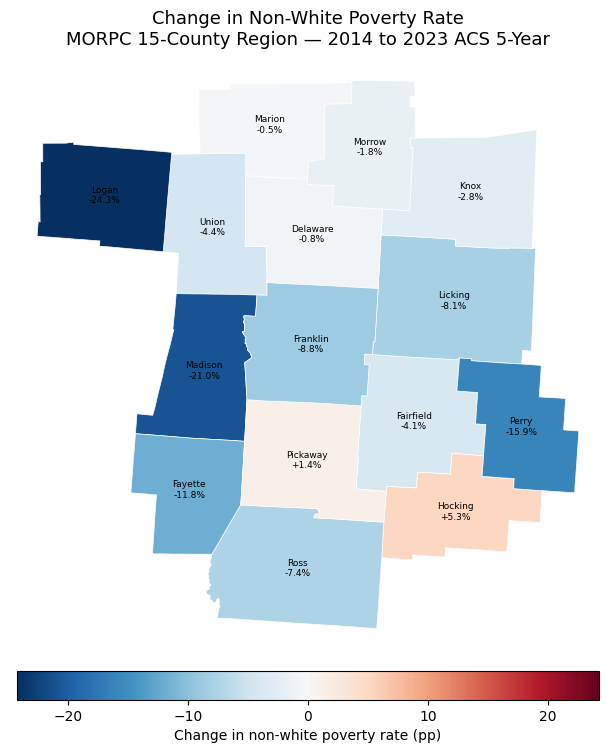

In [144]:
import matplotlib.pyplot as plt

geos_joined = geos.merge(change, left_on='GEOIDFQ', right_on='geoidfq', how='left')

max_abs = geos_joined['change_pp'].abs().max()

fig, ax = plt.subplots(figsize=(10, 8))
geos_joined.plot(
    column='change_pp',
    ax=ax,
    cmap='RdBu_r',
    vmin=-max_abs,
    vmax=max_abs,
    legend=True,
    legend_kwds={
        'label': 'Change in non-white poverty rate (pp)',
        'orientation': 'horizontal',
        'shrink': 0.6,
        'pad': 0.02,
    },
    edgecolor='white',
    linewidth=0.5,
)

for _, row in geos_joined.iterrows():
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    label = row['NAME'].replace(', Ohio', '').replace(' County', '')
    val   = row['change_pp']
    ax.annotate(
        f"{label}\n{val:+.1f}%",
        (cx, cy),
        ha='center', va='center', fontsize=6.5, color='black',
    )

ax.set_title(
    'Change in Non-White Poverty Rate\nMORPC 15-County Region — 2014 to 2023 ACS 5-Year',
    fontsize=13,
)
ax.axis('off')
plt.tight_layout()
plt.show()